In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [3]:
# Load processed data
df = pd.read_csv("../../data/processed/urls_processed.csv")

# only keep features and label for modeling
feature_cols = [c for c in df.columns
                if c not in ["url", "type", "label", "tld"]]

X = df[feature_cols]
y = df["label"]

# map for label names
LABEL_MAP = {0: "benign", 1: "defacement", 2: "phishing", 3: "malware"}

print(f"Features : {X.shape[1]} - {feature_cols}")
print(f"Samples  : {X.shape[0]}")
print(f"\nLabel distribution:")
print(y.value_counts().sort_index().rename(LABEL_MAP))

Features : 14 - ['url_length', 'domain_length', 'path_length', 'num_dots', 'num_slashes', 'num_digits', 'num_special_chars', 'num_subdomains', 'has_https', 'has_ip', 'has_at_symbol', 'has_double_slash', 'query_length', 'num_query_params']
Samples  : 40439

Label distribution:
label
benign        29854
defacement     7455
phishing       2459
malware         671
Name: count, dtype: int64


In [4]:
# Sanity check features
print(" Missing Values")
print(X.isnull().sum())

print(f"\n Inf Values")
print((X == np.inf).sum())

# Xử lý nếu có
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

print(f"\nShape after cleaning: {X.shape}")
print(X.describe().round(2).to_string())

 Missing Values
url_length           0
domain_length        0
path_length          0
num_dots             0
num_slashes          0
num_digits           0
num_special_chars    0
num_subdomains       0
has_https            0
has_ip               0
has_at_symbol        0
has_double_slash     0
query_length         0
num_query_params     0
dtype: int64

 Inf Values
url_length           0
domain_length        0
path_length          0
num_dots             0
num_slashes          0
num_digits           0
num_special_chars    0
num_subdomains       0
has_https            0
has_ip               0
has_at_symbol        0
has_double_slash     0
query_length         0
num_query_params     0
dtype: int64

Shape after cleaning: (40439, 14)
       url_length  domain_length  path_length  num_dots  num_slashes  num_digits  num_special_chars  num_subdomains  has_https    has_ip  has_at_symbol  has_double_slash  query_length  num_query_params
count    40439.00       40439.00     40439.00  40439.00     4043

In [5]:
# Train, Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index().rename(LABEL_MAP))
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index().rename(LABEL_MAP))

Train : 32351 samples
Test  : 8088 samples

Train label distribution:
label
benign        23883
defacement     5964
phishing       1967
malware         537
Name: count, dtype: int64

Test label distribution:
label
benign        5971
defacement    1491
phishing       492
malware        134
Name: count, dtype: int64


In [9]:
# Train Model 1 Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",  # deal with class imbalance
    random_state=42,
    n_jobs=-1                 # use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"\nPer class Report ")
print(classification_report(y_test, rf_pred,
                            target_names=list(LABEL_MAP.values())))

Random Forest Results
Accuracy : 0.9679
Precision: 0.9675
Recall   : 0.9679
F1 Score : 0.9670

Per class Report 
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      5971
  defacement       0.93      0.94      0.94      1491
    phishing       0.94      0.87      0.90       492
     malware       0.92      0.60      0.73       134

    accuracy                           0.97      8088
   macro avg       0.94      0.85      0.89      8088
weighted avg       0.97      0.97      0.97      8088



In [10]:
# Train Model 2 Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Results")
print(f"Accuracy : {accuracy_score(y_test, gb_pred):.4f}")
print(f"Precision: {precision_score(y_test, gb_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, gb_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, gb_pred, average='weighted'):.4f}")
print(f"\nPer class Report ")
print(classification_report(y_test, gb_pred,
                            target_names=list(LABEL_MAP.values())))

Gradient Boosting Results
Accuracy : 0.9686
Precision: 0.9676
Recall   : 0.9686
F1 Score : 0.9675

Per class Report 
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      5971
  defacement       0.94      0.94      0.94      1491
    phishing       0.94      0.88      0.91       492
     malware       0.83      0.55      0.66       134

    accuracy                           0.97      8088
   macro avg       0.92      0.84      0.87      8088
weighted avg       0.97      0.97      0.97      8088



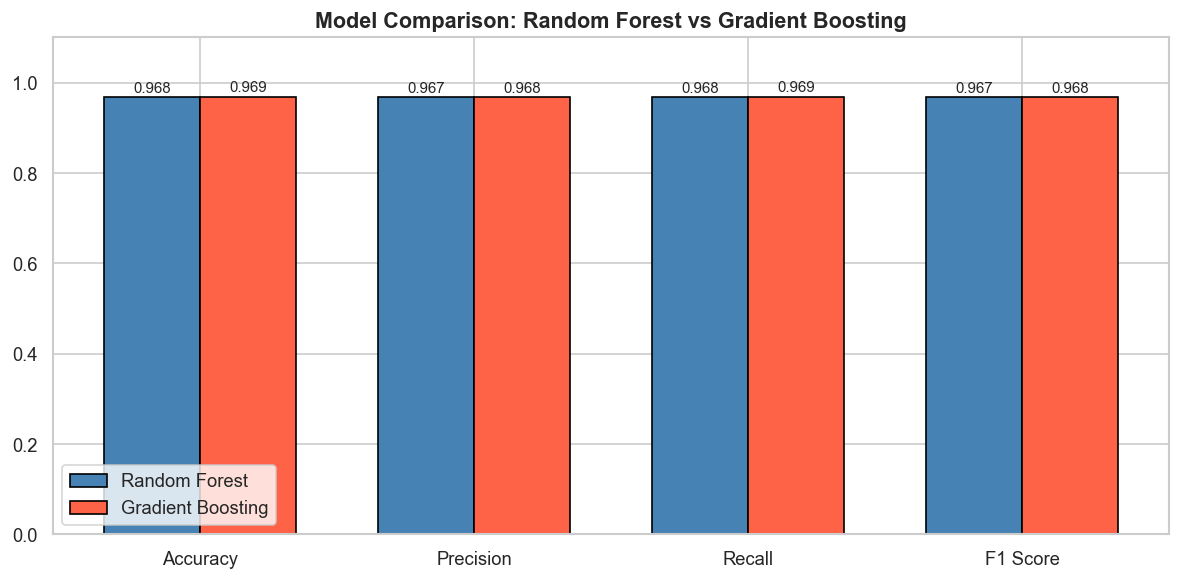

In [11]:
# Compare models
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, average="weighted"),
    recall_score(y_test, rf_pred, average="weighted"),
    f1_score(y_test, rf_pred, average="weighted")
]
gb_scores = [
    accuracy_score(y_test, gb_pred),
    precision_score(y_test, gb_pred, average="weighted"),
    recall_score(y_test, gb_pred, average="weighted"),
    f1_score(y_test, gb_pred, average="weighted")
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rf_scores, width,
               label="Random Forest", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, gb_scores, width,
               label="Gradient Boosting", color="tomato", edgecolor="black")

for bar in bars1.patches + bars2.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Model Comparison: Random Forest vs Gradient Boosting",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

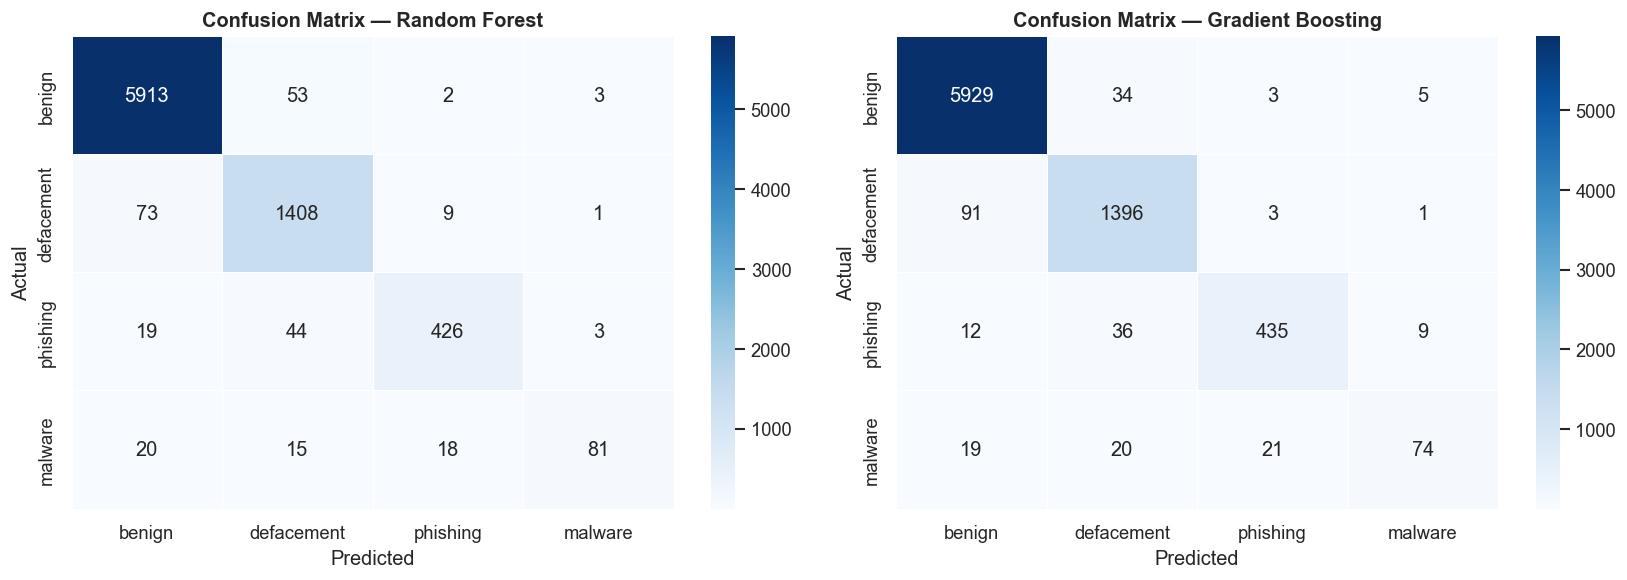

In [12]:
# CELL 8: Confusion Matrix both models
class_names = list(LABEL_MAP.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [rf_pred, gb_pred],
    ["Random Forest", "Gradient Boosting"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_title(f"Confusion Matrix — {title}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

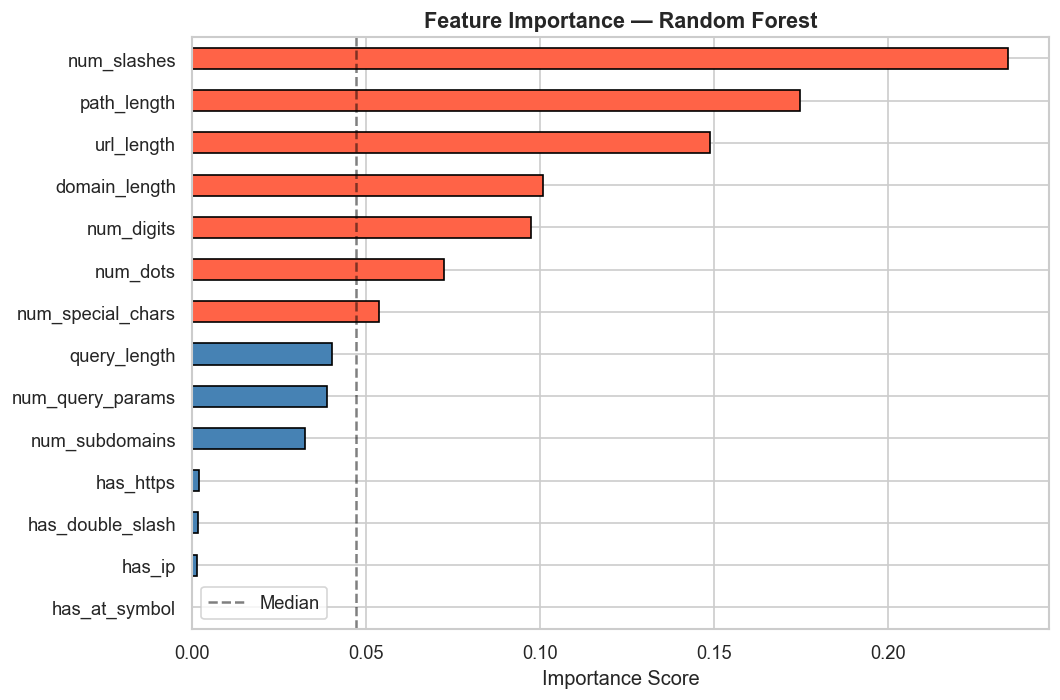

Top 5 Most Important Features
num_slashes      0.2346
path_length      0.1747
url_length       0.1489
domain_length    0.1010
num_digits       0.0975
dtype: float64


In [13]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values()

plt.figure(figsize=(9, 6))
colors = ["tomato" if v > feat_imp.median()
          else "steelblue" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Feature Importance — Random Forest",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.axvline(feat_imp.median(), color="black",
            linestyle="--", alpha=0.5, label="Median")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features")
print(feat_imp.sort_values(ascending=False).head(5).round(4))

In [15]:
#Cross Validation & Save best model
print("5-Fold Cross Validation\n")

for name, model in [("Random Forest", rf_model),
                    ("Gradient Boosting", gb_model)]:
    scores = cross_val_score(model, X, y, cv=5,
                             scoring="f1_weighted", n_jobs=-1)
    print(f"{name}:")
    print(f"  F1 per fold : {scores.round(4)}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std         : {scores.std():.4f}\n")

# Choose best model based on F1 score
rf_f1 = f1_score(y_test, rf_pred, average="weighted")
gb_f1 = f1_score(y_test, gb_pred, average="weighted")

best_model = rf_model if rf_f1 >= gb_f1 else gb_model
best_name  = "Random Forest" if rf_f1 >= gb_f1 else "Gradient Boosting"

print(f"Random Forest F1     : {rf_f1:.4f}")
print(f"Gradient Boosting F1 : {gb_f1:.4f}")
print(f"\n Best model: {best_name}")

# Save
os.makedirs("../../models", exist_ok=True)

with open("../../models/url_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# save feature columns for later use in prediction (must be in same order as training)
with open("../../models/url_feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("\nSaved:")
print("  models/url_model.pkl")
print("  models/url_feature_cols.pkl")

5-Fold Cross Validation

Random Forest:
  F1 per fold : [0.9673 0.9651 0.9628 0.9684 0.9669]
  Mean F1     : 0.9661
  Std         : 0.0020

Gradient Boosting:
  F1 per fold : [0.968  0.9661 0.9663 0.9654 0.9686]
  Mean F1     : 0.9669
  Std         : 0.0012

Random Forest F1     : 0.9670
Gradient Boosting F1 : 0.9675

 Best model: Gradient Boosting

Saved:
  models/url_model.pkl
  models/url_feature_cols.pkl
